In [6]:
import json

with open('pub_games.json', 'r') as file:
    data = json.load(file)

match_ids = sorted([match['match_id'] for match in data])
print('Oldest match = ', match_ids[0])
game_modes = set([match['game_mode'] for match in data])
print(f'{game_modes=}')

max = match_ids[-1]
match_ids[0]/max, match_ids[-1]/max

Oldest match =  7463608213
game_modes={22}


(0.9787826456198954, 1.0)

In [7]:
len(match_ids), len(set(match_ids))

(211227, 211227)

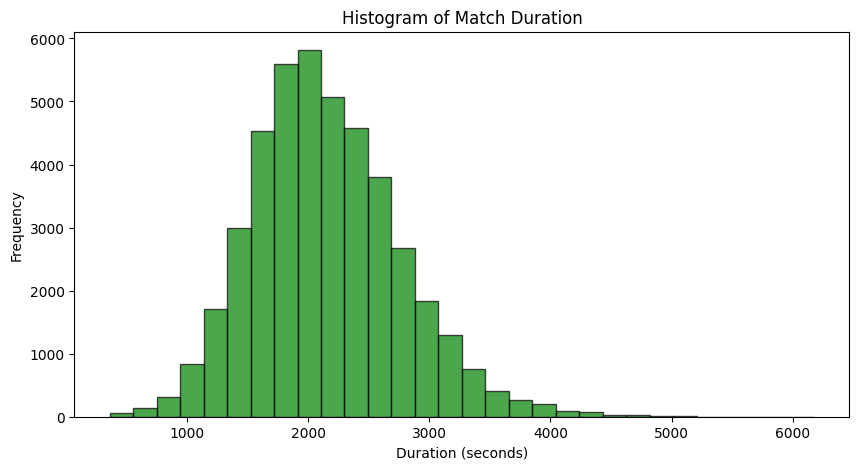

In [92]:
import matplotlib.pyplot as plt
from collections import Counter

# Assuming 'data' is your list of dictionaries

# Extract game_mode and duration from each entry
game_modes = [d['game_mode'] for d in data]
durations = [d['duration'] for d in data]

# Count the frequency of each game_mode
game_mode_counts = Counter(game_modes)

# Prepare the data for plotting
labels, counts = zip(*game_mode_counts.items())

# Plot histogram for duration
plt.figure(figsize=(10, 5))
plt.hist(durations, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Histogram of Match Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


Top 5 Position 1 Heroes:
Pudge: 1964
Nature's Prophet: 1964
Unknown 123: 1896
Slark: 1816
Lion: 1808

Top 5 Position 2 Heroes:
Lion: 2318
Unknown 123: 2271
Pudge: 2132
Vengeful Spirit: 2109
Nature's Prophet: 1908


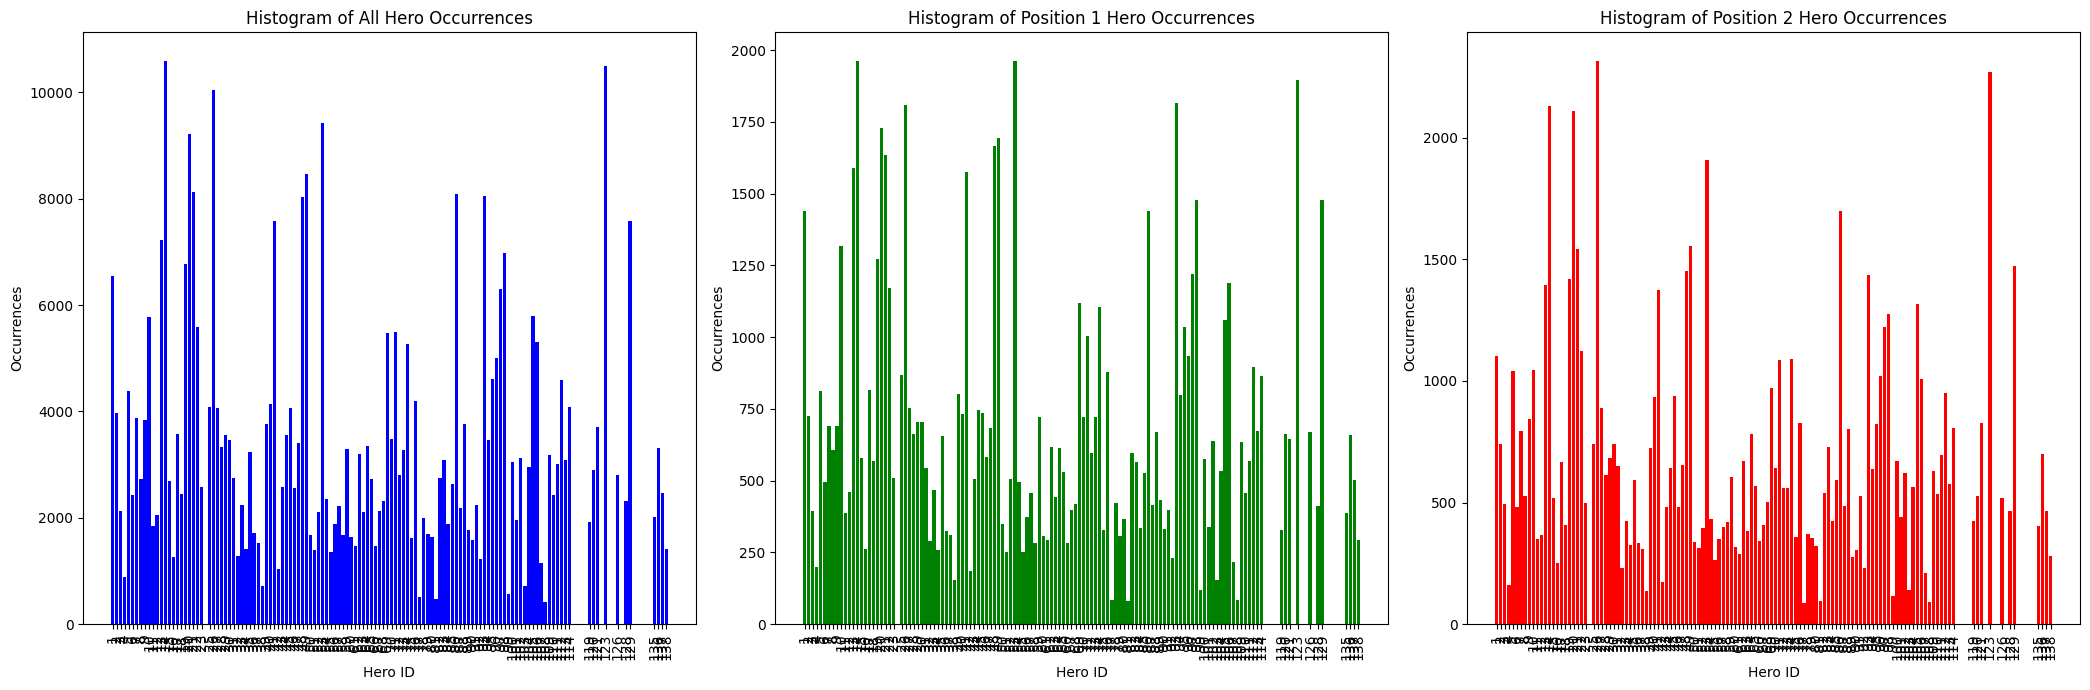

In [107]:
from collections import Counter
import matplotlib.pyplot as plt
import json

# Assuming 'data' is your dataset containing match details

# Combine all heroes from both teams for all matches into a single list
all_heroes = [hero for match in data for team in ['dire_team', 'radiant_team'] for hero in match[team]]

# Extract first and second position heroes for all matches from both teams
all_pos1 = [match[team][0] for match in data for team in ['dire_team', 'radiant_team']]
all_pos2 = [match[team][1] for match in data for team in ['dire_team', 'radiant_team']] # Index corrected to 1 for second position

# Count occurrences for each category
hero_occurrences = Counter(all_heroes)
pos1_occurrences = Counter(all_pos1)
pos2_occurrences = Counter(all_pos2)

# Sort heroes by their ID to maintain order in the plots
sorted_hero_ids = sorted(hero_occurrences.keys())

# Use the sorted_hero_ids to ensure consistency across plots
sorted_all_occurrences = [hero_occurrences[hero_id] for hero_id in sorted_hero_ids]
sorted_pos1_occurrences = [pos1_occurrences.get(hero_id, 0) for hero_id in sorted_hero_ids]
sorted_pos2_occurrences = [pos2_occurrences.get(hero_id, 0) for hero_id in sorted_hero_ids]

###
with open('heroes_dict.json', 'r') as file:
    heroes_dict = json.load(file)

# Get the top 5 heroes for positions 1 and 2
top5_pos1 = pos1_occurrences.most_common(5)
top5_pos2 = pos2_occurrences.most_common(5)

# Convert IDs to hero names for top 5
top5_pos1_names = [(heroes_dict.get(str(hero_id), f'Unknown {hero_id}'), count) for hero_id, count in top5_pos1]
top5_pos2_names = [(heroes_dict.get(str(hero_id), f'Unknown {hero_id}'), count) for hero_id, count in top5_pos2]

# Print the top 5 heroes for positions 1 and 2
print("Top 5 Position 1 Heroes:")
for hero, count in top5_pos1_names:
    print(f"{hero}: {count}")
    
print("\nTop 5 Position 2 Heroes:")
for hero, count in top5_pos2_names:
    print(f"{hero}: {count}")

###

# Plotting
plt.figure(figsize=(21, 7))

# Overall heroes histogram
plt.subplot(1, 3, 1) # 1 row, 3 columns, first subplot
plt.bar(sorted_hero_ids, sorted_all_occurrences, color='blue')
plt.xlabel('Hero ID')
plt.ylabel('Occurrences')
plt.title('Histogram of All Hero Occurrences')
plt.xticks(sorted_hero_ids, rotation='vertical');

# Position 1 heroes histogram
plt.subplot(1, 3, 2) # 1 row, 3 columns, second subplot
plt.bar(sorted_hero_ids, sorted_pos1_occurrences, color='green')
plt.xlabel('Hero ID')
plt.ylabel('Occurrences')
plt.title('Histogram of Position 1 Hero Occurrences')
plt.xticks(sorted_hero_ids, rotation='vertical');

# Position 2 heroes histogram
plt.subplot(1, 3, 3) # 1 row, 3 columns, third subplot
plt.bar(sorted_hero_ids, sorted_pos2_occurrences, color='red')
plt.xlabel('Hero ID')
plt.ylabel('Occurrences')
plt.title('Histogram of Position 2 Hero Occurrences')
plt.xticks(sorted_hero_ids, rotation='vertical');

plt.tight_layout()
plt.show()


In [113]:
heroes_dict['93'], heroes_dict['47'],heroes_dict['83'],heroes_dict['21'],heroes_dict['5']

('Slark', 'Viper', 'Treant Protector', 'Windranger', 'Crystal Maiden')

In [94]:
def create_id_name_dict(hero_list):
    id_name_dict = {}
    for hero in hero_list:
        id_name_dict[hero['id']] = hero['localized_name']
    return id_name_dict


with open('heroes.json', 'r') as file:
    heroes_dict = json.load(file)



result_dict = create_id_name_dict(heroes)
print(result_dict)


{1: 'Anti-Mage', 2: 'Axe', 3: 'Bane', 4: 'Bloodseeker', 5: 'Crystal Maiden', 6: 'Drow Ranger', 7: 'Earthshaker', 8: 'Juggernaut', 9: 'Mirana', 10: 'Morphling', 11: 'Shadow Fiend', 12: 'Phantom Lancer', 13: 'Puck', 14: 'Pudge', 15: 'Razor', 16: 'Sand King', 17: 'Storm Spirit', 18: 'Sven', 19: 'Tiny', 20: 'Vengeful Spirit', 21: 'Windranger', 22: 'Zeus', 23: 'Kunkka', 25: 'Lina', 26: 'Lion', 27: 'Shadow Shaman', 28: 'Slardar', 29: 'Tidehunter', 30: 'Witch Doctor', 31: 'Lich', 32: 'Riki', 33: 'Enigma', 34: 'Tinker', 35: 'Sniper', 36: 'Necrophos', 37: 'Warlock', 38: 'Beastmaster', 39: 'Queen of Pain', 40: 'Venomancer', 41: 'Faceless Void', 42: 'Wraith King', 43: 'Death Prophet', 44: 'Phantom Assassin', 45: 'Pugna', 46: 'Templar Assassin', 47: 'Viper', 48: 'Luna', 49: 'Dragon Knight', 50: 'Dazzle', 51: 'Clockwerk', 52: 'Leshrac', 53: "Nature's Prophet", 54: 'Lifestealer', 55: 'Dark Seer', 56: 'Clinkz', 57: 'Omniknight', 58: 'Enchantress', 59: 'Huskar', 60: 'Night Stalker', 61: 'Broodmother',

In [95]:
file_path = 'heroes_dict.json'
with open(file_path, 'w') as file:
    import json
    json.dump(result_dict, file, indent=4)

In [102]:
set(all_heroes) - set(result_dict.keys())

{114, 119, 120, 121, 123, 126, 128, 129, 135, 136, 137, 138}